# Quantitative-DeFi-Research

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

Attempting to fetch 1h data for ETH-USD from 2024-06-01 to 2025-06-01...
✅ Data fetched successfully! (8735 rows)

--- Data Head ---
Price                        Price_USD  Log_Return  Volatility
Datetime                                                      
2024-06-02 00:00:00+00:00  3830.826416    0.004684    0.002394
2024-06-02 01:00:00+00:00  3821.250488   -0.002503    0.002486
2024-06-02 02:00:00+00:00  3802.046875   -0.005038    0.002686
2024-06-02 03:00:00+00:00  3804.813477    0.000727    0.002686
2024-06-02 04:00:00+00:00  3815.827393    0.002891    0.002732

--- Data Statistics ---
Price    Price_USD   Log_Return   Volatility
count  8735.000000  8735.000000  8735.000000
mean   2776.067017    -0.000047     0.006729
std     623.395994     0.007638     0.003599
min    1415.839355    -0.126705     0.001390
25%    2410.957397    -0.003088     0.004521
50%    2661.896729     0.000084     0.005896
75%    3332.035767     0.003294     0.008025
max    4076.342529     0.096508     0.032

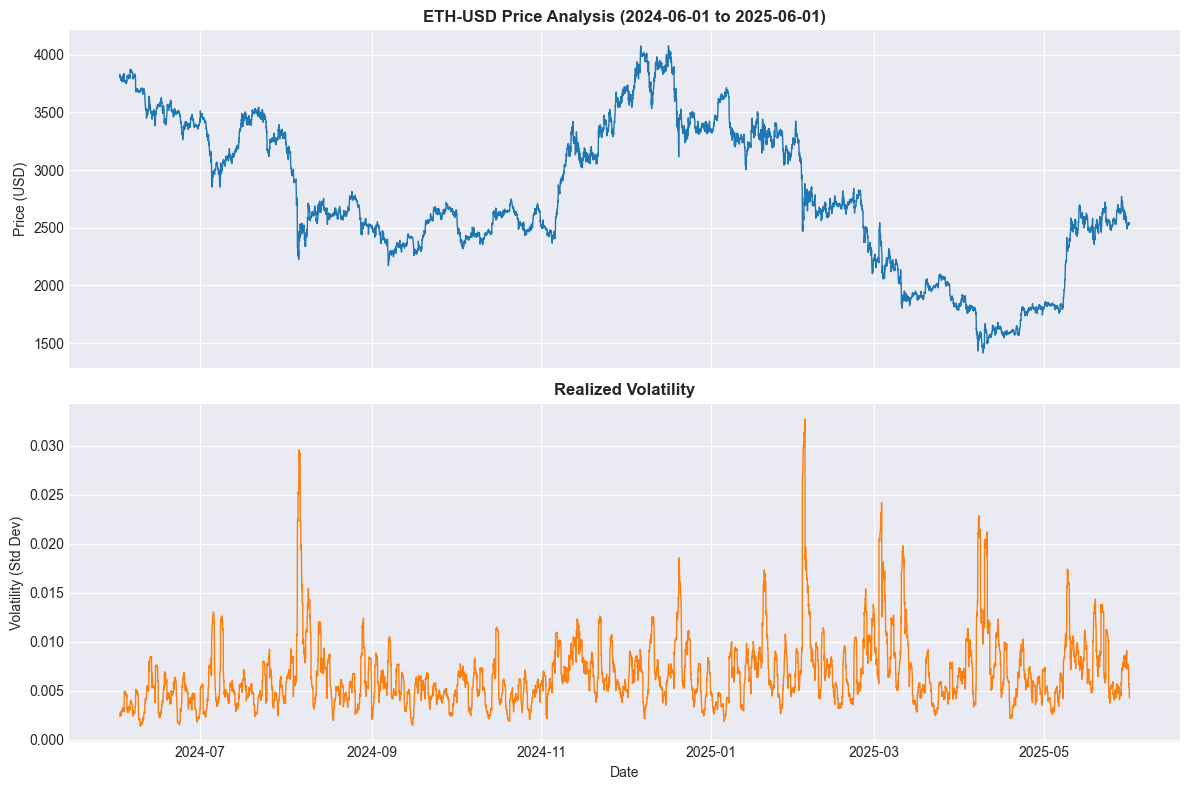


Data saved to 'market_data_clean.csv'


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-darkgrid')

def fetch_market_data(ticker, start_date, end_date, interval='1h'):
    print(f"Attempting to fetch {interval} data for {ticker} from {start_date} to {end_date}...")
    
    try:
        data = yf.download(ticker, start=start_date, end=end_date, interval=interval, progress=False, auto_adjust=True)
    except Exception as e:
        print(f"Error downloading: {e}")
        return pd.DataFrame()
     
    if data.empty:
        print(f"No data found for {interval} interval. Trying '1d' (Daily) interval as fallback...")
        data = yf.download(ticker, start=start_date, end=end_date, interval='1d', progress=False, auto_adjust=True)
    
    if data.empty:
        raise ValueError("Data fetch failed completely. Check your internet or API limits.")

    # Flatten MultiIndex if present
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    
    # Ensure we have the 'Close' column
    if 'Close' not in data.columns:
        # Sometimes yfinance returns 'Adj Close' as 'Close' depending on version
        # If 'Close' is missing, check the columns
        print(f"Available columns: {data.columns}")
        raise KeyError("Could not find 'Close' price column.")

    df = data[['Close']].copy()
    df.rename(columns={'Close': 'Price_USD'}, inplace=True)
    
    # Calculate Log Returns
    df['Log_Return'] = np.log(df['Price_USD'] / df['Price_USD'].shift(1))
    
    # Volatility Calculation 
    # (Window: 24 for hourly = 1 day, 7 for daily = 1 week)
    window = 24 if interval == '1h' else 7
    df['Volatility'] = df['Log_Return'].rolling(window=window).std()
    
    df.dropna(inplace=True)
    print(f"Data fetched successfully! ({len(df)} rows)")
    return df

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    ASSET = 'ETH-USD'
    
    START = '2024-06-01'
    END = '2025-06-01'
    
    try:
        market_data = fetch_market_data(ASSET, START, END, interval='1h')
        
        # Inspection
        print("\n--- Data Head ---")
        print(market_data.head())
        
        print("\n--- Data Statistics ---")
        print(market_data.describe())
        
        # Visualization
        fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        
        # Price
        ax[0].plot(market_data.index, market_data['Price_USD'], color='#1f77b4', lw=1)
        ax[0].set_title(f'{ASSET} Price Analysis ({START} to {END})', fontsize=12, fontweight='bold')
        ax[0].set_ylabel('Price (USD)')
        
        # Volatility
        ax[1].plot(market_data.index, market_data['Volatility'], color='#ff7f0e', lw=1)
        ax[1].set_title('Realized Volatility', fontsize=12, fontweight='bold')
        ax[1].set_ylabel('Volatility (Std Dev)')
        ax[1].set_xlabel('Date')
        
        plt.tight_layout()
        plt.show()
        
        # Save
        market_data.to_csv('data/market_data_clean.csv')
        print("\nData saved to 'market_data_clean.csv'")
        
    except Exception as e:
        print(f"\nCRITICAL ERROR: {e}")